# Importación de las librerías necesarias para la ejecución #

In [420]:
#Librerias Necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense
from keras import backend as K

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
#from sklearn.preprocessing import scale

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Lectura de los datos de los partidos ya formateados en .csv

In [421]:
# Lista para almacenar los DataFrames leídos
dataframes = []

# Leer los archivos CSV que contienen los DataFrames
archivos = ['datos-1011.csv','datos-1112.csv','datos-1213.csv','datos-1314.csv',
            'datos-1415.csv','datos-1516.csv', 'datos-1617.csv', 'datos-1718.csv',
            'datos-1819.csv', 'datos-1920.csv', 'datos-2021.csv', 'datos-2122.csv', 
            'datos-2223.csv', 'datos-2324.csv']

archivos_segunda = ['datos-SP2-1011.csv','datos-SP2-1112.csv',
            'datos-SP2-1213.csv','datos-SP2-1314.csv','datos-SP2-1415.csv','datos-SP2-1516.csv', 
            'datos-SP2-1617.csv', 'datos-SP2-1718.csv','datos-SP2-1819.csv', 'datos-SP2-1920.csv', 
            'datos-SP2-2021.csv', 'datos-SP2-2122.csv', 'datos-SP2-2223.csv', 'datos-SP2-2324.csv']

#archivos += archivos_segunda

for archivo in archivos:
    # Leer el archivo y almacenar el DataFrame en la lista
    df = pd.read_csv("../Segundo_Dataset/Datos_Formateados/"+archivo)
    dataframes.append(df)

# Concatenar todos los DataFrames en uno solo
datos_partidos = pd.concat(dataframes, ignore_index=True)
datos_partidos.shape

(5199, 9)

In [422]:
datos_partidos.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,FTR
0,SP1,28/08/10,Hercules,Ath Bilbao,0,1,0,0,A
1,SP1,28/08/10,Levante,Sevilla,1,4,1,2,A
2,SP1,28/08/10,Malaga,Valencia,1,3,1,1,A
3,SP1,29/08/10,Espanol,Getafe,3,1,1,0,H
4,SP1,29/08/10,La Coruna,Zaragoza,0,0,0,0,D


In [423]:
def get_equipos(dataframe: pd.DataFrame) -> list:
    list = []
    for idx in dataframe.index:
        if dataframe['HomeTeam'][idx] not in list:
            list.append(dataframe['HomeTeam'][idx])
        if dataframe['AwayTeam'][idx] not in list:
            list.append(dataframe['AwayTeam'][idx])
    return list

equipos = get_equipos(dataframe=datos_partidos)
equipos

['Hercules',
 'Ath Bilbao',
 'Levante',
 'Sevilla',
 'Malaga',
 'Valencia',
 'Espanol',
 'Getafe',
 'La Coruna',
 'Zaragoza',
 'Mallorca',
 'Real Madrid',
 'Osasuna',
 'Almeria',
 'Santander',
 'Barcelona',
 'Sociedad',
 'Villarreal',
 'Ath Madrid',
 'Sp Gijon',
 'Granada',
 'Betis',
 'Vallecano',
 'Celta',
 'Valladolid',
 'Elche',
 'Eibar',
 'Cordoba',
 'Las Palmas',
 'Alaves',
 'Leganes',
 'Girona',
 'Huesca',
 'Cadiz']

# Predicción del ganador de un partido sabiendo el nombre de los equipos 

## - Pre-procesamiento de los datos ##

### Limpiado de valores de la columna FTR diferentes a [A,D,H]

In [424]:
condicion = (datos_partidos['FTR'] != 'A') & (datos_partidos['FTR'] != 'H') & (datos_partidos['FTR'] != 'D')
datos_partidos = datos_partidos.drop(datos_partidos[condicion].index)

### Adición de la racha de los equipos

In [425]:
def calcular_racha_invicto(fila_actual, racha_anterior, local):
    if local == True:
        resultado_actual = fila_actual['FTR']
        if resultado_actual == 'H':
            racha_actual = racha_anterior+1
        elif resultado_actual == 'D':
            racha_actual = racha_anterior
        else:
            racha_actual = 0
        return racha_actual
    else:
        resultado_actual = fila_actual['FTR']
        if resultado_actual == 'A':
            racha_actual = racha_anterior+1
        elif resultado_actual == 'D':
            racha_actual = racha_anterior
        else:
            racha_actual = 0
        return racha_actual


for equipo in equipos:
    nueva_columna_valores = []
    racha_actual = 0
    first = True
    filas_filtradas = datos_partidos[datos_partidos['HomeTeam'] == equipo]
    for indice, fila_actual in filas_filtradas.iterrows():
        if first:
            first = False
            nueva_columna_valores.append(0)
            racha_actual = calcular_racha_invicto(fila_actual, racha_actual, True)
        else:
            nueva_columna_valores.append(racha_actual)
            racha_actual = calcular_racha_invicto(fila_actual, racha_actual, True)

    datos_partidos.loc[filas_filtradas.index, 'Racha Local'] = nueva_columna_valores
    
for equipo in equipos:
    nueva_columna_valores = []
    racha_actual = 0
    first = True
    filas_filtradas = datos_partidos[datos_partidos['AwayTeam'] == equipo]
    for indice, fila_actual in filas_filtradas.iterrows():
        if first:
            first = False
            nueva_columna_valores.append(0)
            racha_actual = calcular_racha_invicto(fila_actual, racha_actual, False)
        else:
            nueva_columna_valores.append(racha_actual)
            racha_actual = calcular_racha_invicto(fila_actual, racha_actual, False)

    datos_partidos.loc[filas_filtradas.index, 'Racha Visitante'] = nueva_columna_valores
    
datos_partidos.to_csv("intermedio.csv")


### Asignación de etiquetas numéricas a los posibles valores de FTR, HomeTeam y AwayTeam

In [426]:
lb_make = LabelEncoder()
datos_partidos['target FTR'] = lb_make.fit_transform(datos_partidos['FTR'])
datos_partidos['FTR'].value_counts()
label_encoder = LabelEncoder()
datos_partidos['labeled Home'] = label_encoder.fit_transform(datos_partidos['HomeTeam'])
datos_partidos['labeled Away'] = label_encoder.fit_transform(datos_partidos['AwayTeam'])

In [427]:
datos_partidos['FTR'].value_counts()

FTR
H    2425
A    1468
D    1306
Name: count, dtype: int64

In [428]:
datos_partidos['target FTR'].value_counts()

target FTR
2    2425
0    1468
1    1306
Name: count, dtype: int64

### Normalización de los rachas invictos

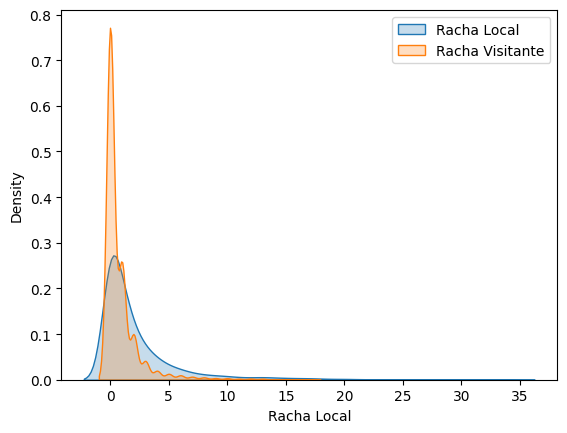

In [429]:
columnas_rachas = ['Racha Local','Racha Visitante']
rachas = datos_partidos[columnas_rachas]
for i, col in enumerate(rachas.columns):
    sns.kdeplot(rachas[col], fill=True, label=columnas_rachas[i])
plt.legend()
plt.show()

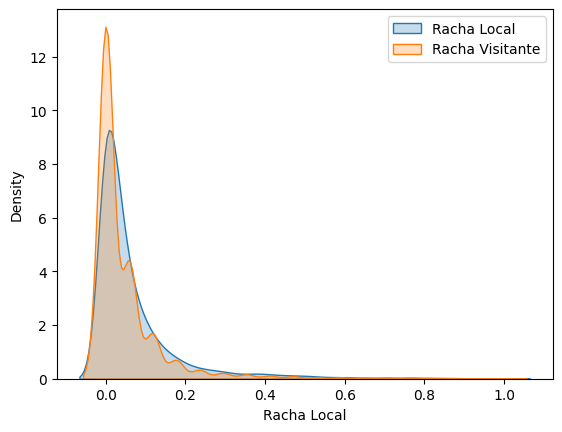

In [430]:
scale = MinMaxScaler().fit(rachas)
rachas_normalized = scale.transform(rachas)
rachas_normalized_dataframe = pd.DataFrame(rachas_normalized, columns=columnas_rachas)
i = 0
for col in rachas_normalized_dataframe:
    sns.kdeplot(rachas_normalized_dataframe[col], fill=True, label=columnas_rachas[i])
    i+=1
plt.legend()
plt.show()

In [431]:
rachas_normalized_dataframe.shape

(5199, 2)

In [432]:
rachas_normalized_dataframe.head()

,Racha Local,Racha Visitante
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [433]:
datos_partidos[rachas_normalized_dataframe.columns] = rachas_normalized_dataframe
datos_partidos.to_csv("prueba.csv")
datos_partidos.shape

(5199, 14)

### Definición de los predictores y del objetivo de predicción ###
| Variable | Descripción
| :-------- | :-------:
| HomeTeam | Nombre del equipo local
| AwayTeam | Nombre del equipo visitante
| FTR | Ganador del partido (Home, Draw, Away)
| target FTR | Ganador del partido (2, 1, 0)

In [434]:
equipos_locales = datos_partidos['labeled Home']
equipos_visitantes = datos_partidos['labeled Away']
rachas = datos_partidos[['Racha Local','Racha Visitante']]
target = datos_partidos['target FTR']

### Separación del objetivo de predicción en clases binarias

In [435]:
target = to_categorical(target)
target.shape

(5199, 3)

## - Normalización de los datos

Ahora mismo, los dos predictores son variables categóricas de tipo string. Estos no pueden ser alimentados directamente al modelo ya que podría ocasionar algún error. Antes deben ser procesados y convertidos a un valor númerico fácilmente interpretable por el modelo. Para lograr esto, utilizo la opción del **One-shot encoding**

In [436]:
onehot_encoder = OneHotEncoder(sparse_output=False)
equipos_encoded = onehot_encoder.fit_transform(np.array([equipos_locales, equipos_visitantes]).T)
equipos_encoded.shape

(5199, 68)

In [437]:
rachas.shape

(5199, 2)

In [438]:
predictores = np.concatenate([equipos_encoded,rachas], axis=1)

## - Entrenamiento del modelo

### División del dataset en entrenamiento y evaluación del modelo

In [439]:
features_train, features_test, target_train, target_test = train_test_split( predictores, target, test_size=0.3, random_state=4)
print ('Train set:', features_train.shape,  target_train.shape)
print ('Test set:', features_test.shape,  target_test.shape)

Train set: (3639, 70) (3639, 3)
Test set: (1560, 70) (1560, 3)


### Definición y construcción del modelo

In [450]:
def get_modelo_regresion(features: pd.DataFrame) -> Sequential:
    numero_predictores = features.shape[1]
    #Crear el modelo
    model = Sequential()
    model.add(Dense(70, activation='relu', input_shape=(numero_predictores,)))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(40, activation='relu'))
    model.add(Dense(30, activation='relu'))
    model.add(Dense(10, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    
    #Compilar modelo
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

modelo = get_modelo_regresion(features=predictores)

### Entrenamiento del modelo

In [451]:
iteraciones=7
historial_entrenamiento=modelo.fit(features_train, target_train, validation_data=(features_test,target_test), epochs=iteraciones, verbose=1)

Epoch 1/7
114/114 [==============================] - 5s 16ms/step - loss: 1.0394 - accuracy: 0.4688 - val_loss: 1.0126 - val_accuracy: 0.4949
Epoch 2/7
114/114 [==============================] - 1s 11ms/step - loss: 0.9869 - accuracy: 0.5320 - val_loss: 0.9895 - val_accuracy: 0.5224
Epoch 3/7
114/114 [==============================] - 1s 10ms/step - loss: 0.9659 - accuracy: 0.5419 - val_loss: 0.9851 - val_accuracy: 0.5288
Epoch 4/7
114/114 [==============================] - 1s 10ms/step - loss: 0.9540 - accuracy: 0.5474 - val_loss: 0.9869 - val_accuracy: 0.5199
Epoch 5/7
114/114 [==============================] - 1s 10ms/step - loss: 0.9440 - accuracy: 0.5510 - val_loss: 0.9865 - val_accuracy: 0.5160
Epoch 6/7
114/114 [==============================] - 1s 10ms/step - loss: 0.9348 - accuracy: 0.5598 - val_loss: 0.9984 - val_accuracy: 0.5199
Epoch 7/7
114/114 [==============================] - 1s 10ms/step - loss: 0.9266 - accuracy: 0.5625 - val_loss: 1.0036 - val_accuracy: 0.5173


## -Evaluación del modelo

### Evolución del modelo

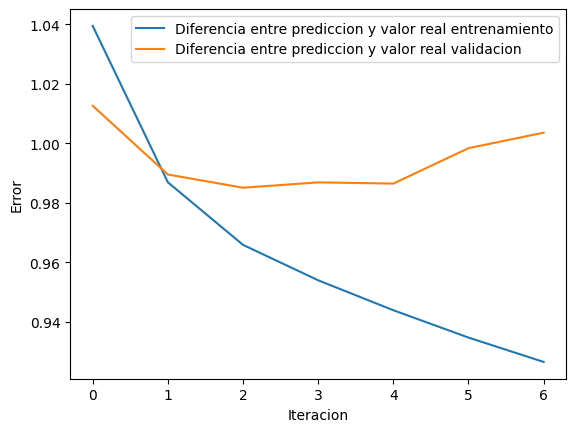

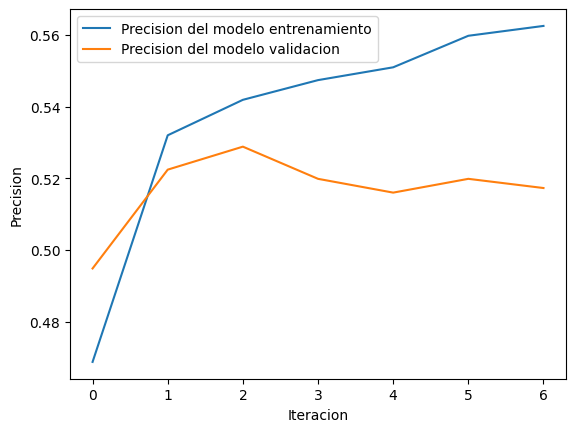

In [452]:
def plot_entrenamiento(historial):
    hist = pd.DataFrame(historial.history)
    hist['iteracion'] = historial.epoch

    plt.figure()
    plt.xlabel('Iteracion')
    plt.ylabel('Error')
    plt.plot(hist['iteracion'], hist['loss'],label='Diferencia entre prediccion y valor real entrenamiento')
    plt.plot(hist['iteracion'], hist['val_loss'],label = 'Diferencia entre prediccion y valor real validacion')
    plt.legend()
    
    plt.figure()
    plt.xlabel('Iteracion')
    plt.ylabel('Precision')
    plt.plot(hist['iteracion'], hist['accuracy'],label='Precision del modelo entrenamiento')
    plt.plot(hist['iteracion'], hist['val_accuracy'],label = 'Precision del modelo validacion')
    plt.legend()
    
    plt.show()
    
plot_entrenamiento(historial = historial_entrenamiento)

### Evaluación

In [379]:
test1 = modelo.evaluate(features_test, target_test, verbose=0)
print('Test loss:', round(test1[0],3)) 
print('Test accuracy:', round(test1[1],3))

Test loss: 0.993
Test accuracy: 0.512


## - Predicción real de un partido

In [389]:
'''
HT='Barcelona'
AT='Malaga'
datos_partido_a_predecir=datos_partidos.loc[(datos_partidos['HomeTeam']==HT) & (datos_partidos['AwayTeam']==AT)]
print(datos_partido_a_predecir.shape)
print(datos_partido_a_predecir)
'''
HT='Las Palmas'
AT='Getafe'
filas_filtradas_local = datos_partidos[datos_partidos['HomeTeam'] == HT]
racha_local = filas_filtradas_local.iloc[-1]['Racha Local']
print(racha_local)
filas_filtradas_visitante = datos_partidos[datos_partidos['AwayTeam'] == HT]
racha_visitante = filas_filtradas_visitante.iloc[-1]['Racha Visitante']
print(racha_visitante)

0.029411764705882353
0.058823529411764705


### Normalizar los predictores teniendo en cuenta los predictores usados para el entrenamiento del modelo

In [390]:
local = [HT,]
visitante = [AT,]
locales_encoded = label_encoder.transform(local)
visitantes_encoded = label_encoder.transform(visitante)

equipos_encoded = onehot_encoder.transform(np.array([locales_encoded, visitantes_encoded]).T)
equipos_encoded.shape

(1, 68)

In [391]:
predictores = np.append(equipos_encoded, [[racha_local, racha_visitante]], axis=1)
predictores.shape

(1, 70)

### Predicción del valor objetivo

In [392]:
pred1 = modelo.predict(predictores)
pred1

1/1 [==============================] - 0s 70ms/step


array([[0.2757083 , 0.27368477, 0.450607  ]], dtype=float32)

### Conversión del número devuelto
Puede que el valor de las probabilidades devuelto por el modelo sea muy pequeño así que se opera para ser un número más manejable

In [393]:
def convertir_numbero(prediccion: list) -> list:
    prediccion_valores=[]
    for i in range(len(prediccion[0])):
      pred_number=float(format(prediccion[0][i], '.3f'))
      prediccion_valores.append(pred_number)

    return (prediccion_valores)
  
pred1_number_probabilities=convertir_numbero(pred1)

### Obtención del resultado predicho en base a las probabilidades predichas por el modelo

In [394]:
def get_ganador_prediccion(ganador: list) -> str:
    y=ganador.index(max(ganador))
    if y==0:
        pred_winner='Away'
    elif y==1:
        pred_winner='Draw'
    else:
        pred_winner='Home'
    return pred_winner

ganador_predicho=get_ganador_prediccion(pred1_number_probabilities)

### Resultado Final

In [395]:
#print('El ganador real es: ', ganador_real)
print('El ganador predicho es: ',ganador_predicho)

El ganador predicho es:  Home


### Visualización de las probabilidades en una gráfica

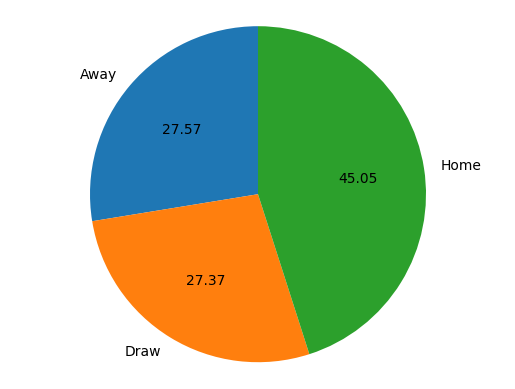

In [396]:
etiquetas = 'Away', 'Draw', 'Home'
figureObject, axesObject = plt.subplots()
axesObject.pie(pred1_number_probabilities, labels=etiquetas, autopct='%1.2f', startangle=90)
axesObject.axis('equal') # Aspect ratio equal means pie is a circle
plt.show()